In [1]:
from pathlib import Path
import torch
import torch.nn as nn
import torch.nn.functional as F
import numpy as np
import matplotlib.pyplot as plt
import time

if torch.backends.mps.is_available():
    device = torch.device('mps')
elif torch.cuda.is_available():
    device = torch.device('cuda')
else:
    device = torch.device('cpu')

print(f"Using device: {device}")

MODEL_SAVE_PATH = "../model"
RESULT_SAVE_PATH = "../result"

Path(MODEL_SAVE_PATH).mkdir(parents=True, exist_ok=True)
Path(RESULT_SAVE_PATH).mkdir(parents=True, exist_ok=True)

Using device: mps


# A6.1 卷积神经网络中卷积核分析实验

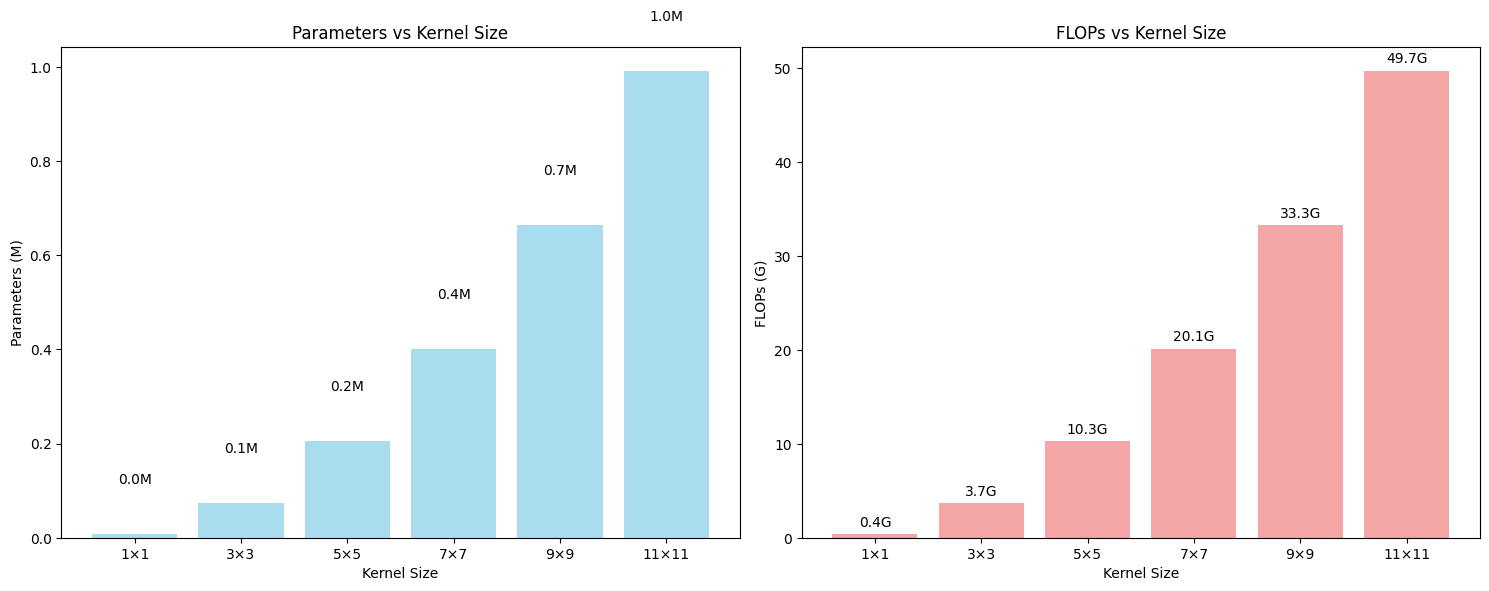

参数量和计算量分析:
1×1 卷积核: 参数量 0.01M, 计算量 0.41G FLOPs
3×3 卷积核: 参数量 0.07M, 计算量 3.70G FLOPs
5×5 卷积核: 参数量 0.20M, 计算量 10.28G FLOPs
7×7 卷积核: 参数量 0.40M, 计算量 20.14G FLOPs
9×9 卷积核: 参数量 0.66M, 计算量 33.29G FLOPs
11×11 卷积核: 参数量 0.99M, 计算量 49.74G FLOPs


In [ ]:
def count_conv_parameters(in_channels, out_channels, kernel_size):
    """计算卷积层参数量"""
    if isinstance(kernel_size, int):
        kernel_size = (kernel_size, kernel_size)
    return in_channels * out_channels * kernel_size[0] * kernel_size[1] + out_channels

def count_conv_flops(input_shape, kernel_size, out_channels):
    """计算卷积层FLOPs"""
    H, W, C = input_shape
    if isinstance(kernel_size, int):
        kernel_size = (kernel_size, kernel_size)
    return H * W * kernel_size[0] * kernel_size[1] * C * out_channels

# 实验1: 不同卷积核大小的参数量和计算量分析
kernel_sizes = [1, 3, 5, 7, 9, 11]
in_channels = 64
out_channels = 128
input_shape = (224, 224, 64)  # H, W, C

params = []
flops = []

for k in kernel_sizes:
    param_count = count_conv_parameters(in_channels, out_channels, k)
    flop_count = count_conv_flops(input_shape, k, out_channels)
    params.append(param_count)
    flops.append(flop_count / 1e9)  # 转换为GFLOPs

fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(15, 6))

ax1.bar(range(len(kernel_sizes)), [p/1e6 for p in params], color='skyblue', alpha=0.7)
ax1.set_xlabel('Kernel Size')
ax1.set_ylabel('Parameters (M)')
ax1.set_title('Parameters vs Kernel Size')
ax1.set_xticks(range(len(kernel_sizes)))
ax1.set_xticklabels([f'{k}×{k}' for k in kernel_sizes])
for i, v in enumerate(params):
    ax1.text(i, v/1e6 + 0.1, f'{v/1e6:.1f}M', ha='center', va='bottom')

ax2.bar(range(len(kernel_sizes)), flops, color='lightcoral', alpha=0.7)
ax2.set_xlabel('Kernel Size')
ax2.set_ylabel('FLOPs (G)')
ax2.set_title('FLOPs vs Kernel Size')
ax2.set_xticks(range(len(kernel_sizes)))
ax2.set_xticklabels([f'{k}×{k}' for k in kernel_sizes])
for i, v in enumerate(flops):
    ax2.text(i, v + 0.5, f'{v:.1f}G', ha='center', va='bottom')

plt.tight_layout()
plt.savefig(f'{RESULT_SAVE_PATH}/conv_kernel_comparison.png', dpi=300, bbox_inches='tight')
plt.show()

print("参数量和计算量分析:")
for i, k in enumerate(kernel_sizes):
    print(f"{k}×{k} 卷积核: 参数量 {params[i]/1e6:.2f}M, 计算量 {flops[i]:.2f}G FLOPs")

# 实验2: 1×1卷积核的降维效果分析

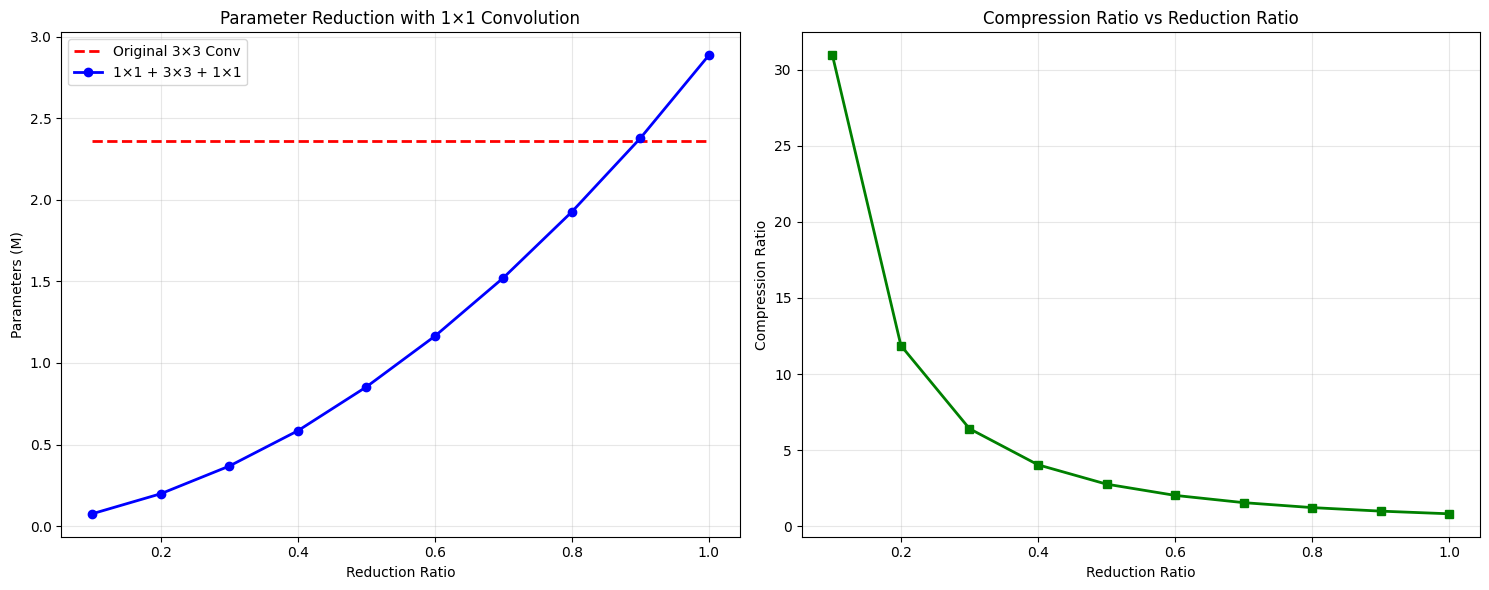

1×1卷积降维效果:
原始3×3卷积参数量: 2.36M
降维比例0.1: 参数量0.08M, 压缩比30.95x
降维比例0.2: 参数量0.20M, 压缩比11.87x
降维比例0.3: 参数量0.37M, 压缩比6.41x
降维比例0.4: 参数量0.58M, 压缩比4.04x
降维比例0.5: 参数量0.85M, 压缩比2.77x
降维比例0.6: 参数量1.16M, 压缩比2.03x
降维比例0.7: 参数量1.52M, 压缩比1.55x
降维比例0.8: 参数量1.93M, 压缩比1.23x
降维比例0.9: 参数量2.38M, 压缩比0.99x
降维比例1.0: 参数量2.89M, 压缩比0.82x


In [ ]:
class Conv1x1Block(nn.Module):
    def __init__(self, in_channels, out_channels):
        super().__init__()
        self.conv = nn.Conv2d(in_channels, out_channels, 1)
        self.bn = nn.BatchNorm2d(out_channels)
        self.relu = nn.ReLU(inplace=True)
    
    def forward(self, x):
        return self.relu(self.bn(self.conv(x)))

input_channels = 512
reduction_ratios = [0.1, 0.2, 0.3, 0.4, 0.5, 0.6, 0.7, 0.8, 0.9, 1.0]
input_tensor = torch.randn(1, input_channels, 32, 32).to(device)

original_params = count_conv_parameters(input_channels, input_channels, 3)
original_flops = count_conv_flops((32, 32, input_channels), 3, input_channels)

reduced_params = []
reduced_flops = []
compression_ratios = []

for ratio in reduction_ratios:
    reduced_channels = int(input_channels * ratio)
    
    # 1×1降维 + 3×3卷积 + 1×1升维
    conv1x1_down_params = count_conv_parameters(input_channels, reduced_channels, 1)
    conv3x3_params = count_conv_parameters(reduced_channels, reduced_channels, 3)
    conv1x1_up_params = count_conv_parameters(reduced_channels, input_channels, 1)
    
    total_params = conv1x1_down_params + conv3x3_params + conv1x1_up_params
    
    conv1x1_down_flops = count_conv_flops((32, 32, input_channels), 1, reduced_channels)
    conv3x3_flops = count_conv_flops((32, 32, reduced_channels), 3, reduced_channels)
    conv1x1_up_flops = count_conv_flops((32, 32, reduced_channels), 1, input_channels)
    
    total_flops = conv1x1_down_flops + conv3x3_flops + conv1x1_up_flops
    
    reduced_params.append(total_params)
    reduced_flops.append(total_flops)
    compression_ratios.append(original_params / total_params)

fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(15, 6))

ax1.plot(reduction_ratios, [original_params/1e6] * len(reduction_ratios), 
         'r--', label='Original 3×3 Conv', linewidth=2)
ax1.plot(reduction_ratios, [p/1e6 for p in reduced_params], 
         'b-o', label='1×1 + 3×3 + 1×1', linewidth=2, markersize=6)
ax1.set_xlabel('Reduction Ratio')
ax1.set_ylabel('Parameters (M)')
ax1.set_title('Parameter Reduction with 1×1 Convolution')
ax1.legend()
ax1.grid(True, alpha=0.3)

ax2.plot(reduction_ratios, compression_ratios, 'g-s', linewidth=2, markersize=6)
ax2.set_xlabel('Reduction Ratio')
ax2.set_ylabel('Compression Ratio')
ax2.set_title('Compression Ratio vs Reduction Ratio')
ax2.grid(True, alpha=0.3)

plt.tight_layout()
plt.savefig(f'{RESULT_SAVE_PATH}/conv1x1_reduction_effect.png', dpi=300, bbox_inches='tight')
plt.show()

print("1×1卷积降维效果:")
print(f"原始3×3卷积参数量: {original_params/1e6:.2f}M")
for i, ratio in enumerate(reduction_ratios):
    print(f"降维比例{ratio:.1f}: 参数量{reduced_params[i]/1e6:.2f}M, 压缩比{compression_ratios[i]:.2f}x")

# 实验3: 感受野分析

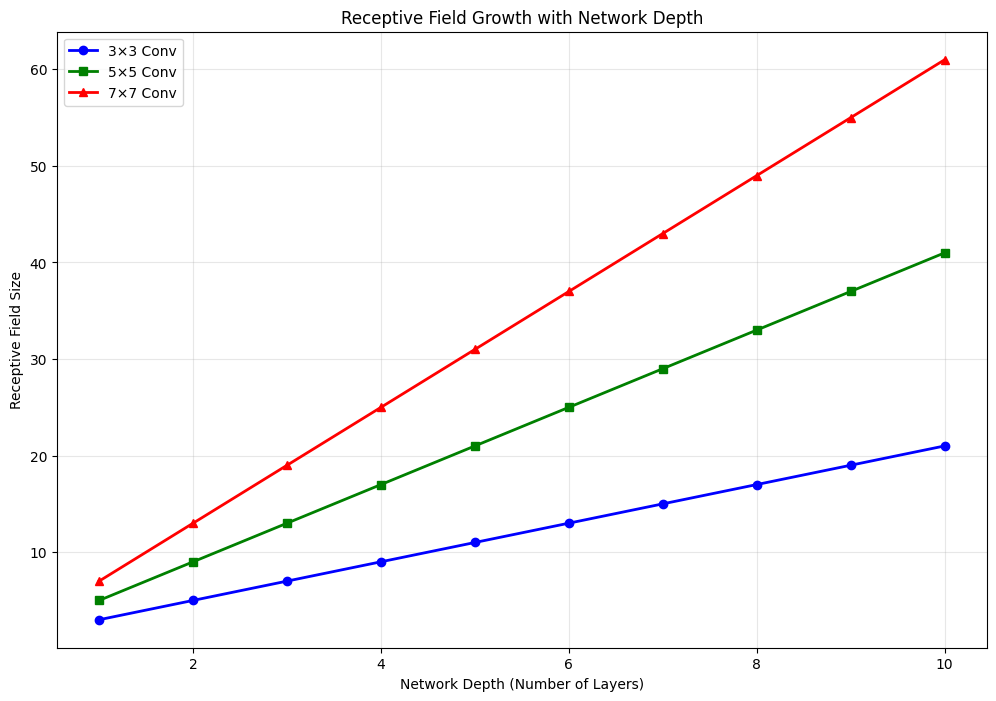

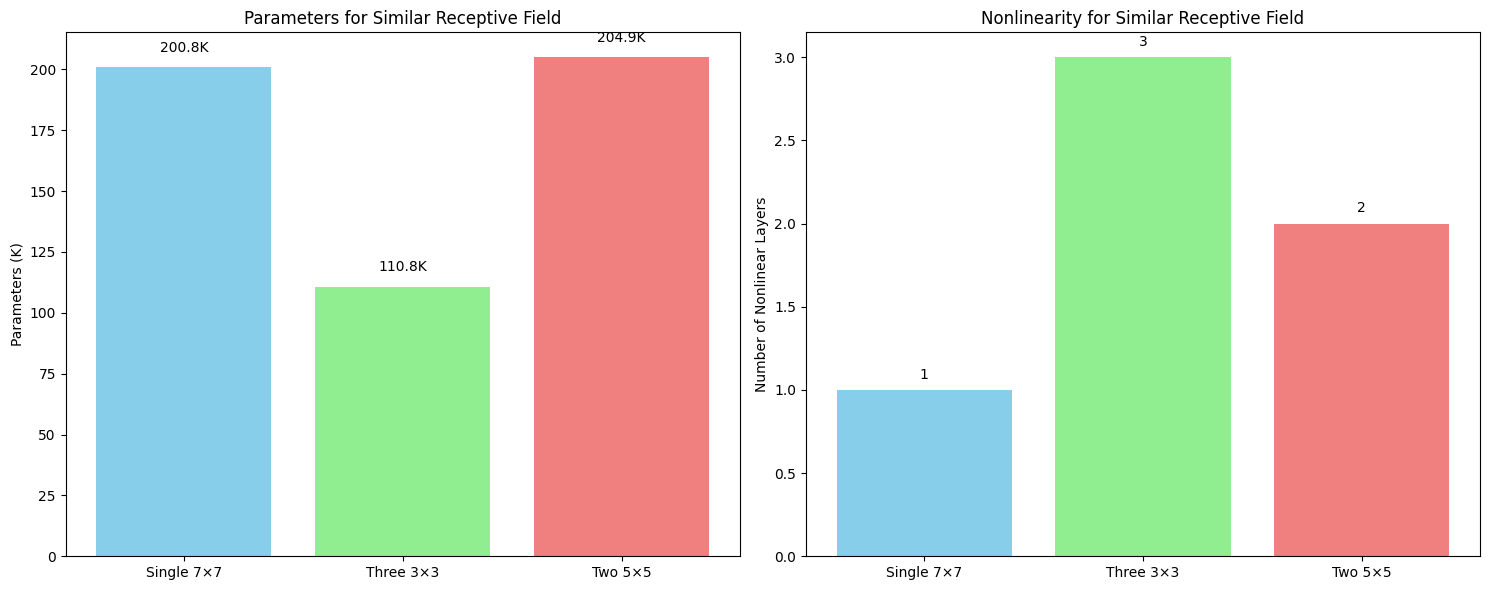

感受野分析结果:
单个7×7卷积: 感受野7, 参数量200,768
三个3×3卷积: 感受野7, 参数量110,784
参数效率提升: 1.81x


In [ ]:
def calculate_receptive_field(layers_info):
    """计算网络的感受野大小"""
    rf = 1
    stride_product = 1
    
    for kernel_size, stride in layers_info:
        rf = rf + (kernel_size - 1) * stride_product
        stride_product *= stride
    
    return rf

# 情况1: 单个大卷积核
large_kernel_rf = calculate_receptive_field([(7, 1)])

# 情况2: 多个小卷积核堆叠
small_kernel_stack_rf = calculate_receptive_field([(3, 1), (3, 1), (3, 1)])

# 情况3: 不同深度的网络
depths = range(1, 11)
kernel_sizes = [3, 5, 7]
colors = ['b', 'g', 'r']
markers = ['o', 's', '^']
labels = ['3×3 Conv', '5×5 Conv', '7×7 Conv']

plt.figure(figsize=(12, 8))

for i, k in enumerate(kernel_sizes):
    rfs = []
    for depth in depths:
        layers = [(k, 1)] * depth
        rf = calculate_receptive_field(layers)
        rfs.append(rf)
    
    plt.plot(depths, rfs, color=colors[i], marker=markers[i], label=labels[i], 
             linewidth=2, markersize=6)

plt.xlabel('Network Depth (Number of Layers)')
plt.ylabel('Receptive Field Size')
plt.title('Receptive Field Growth with Network Depth')
plt.legend()
plt.grid(True, alpha=0.3)
plt.savefig(f'{RESULT_SAVE_PATH}/receptive_field_analysis.png', dpi=300, bbox_inches='tight')
plt.show()

fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(15, 6))

target_rf = 7
architectures = []
param_counts = []
arch_names = []

# 单个7×7卷积
arch_names.append('Single 7×7')
param_counts.append(count_conv_parameters(64, 64, 7))

# 三个3×3卷积堆叠 (感受野: 1 + (3-1) + (3-1) + (3-1) = 7)
arch_names.append('Three 3×3')
param_counts.append(3 * count_conv_parameters(64, 64, 3))

# 两个5×5卷积 (感受野: 1 + (5-1) + (5-1) = 9, 超过目标)
arch_names.append('Two 5×5')
param_counts.append(2 * count_conv_parameters(64, 64, 5))

ax1.bar(arch_names, [p/1e3 for p in param_counts], color=['skyblue', 'lightgreen', 'lightcoral'])
ax1.set_ylabel('Parameters (K)')
ax1.set_title('Parameters for Similar Receptive Field')
for i, v in enumerate(param_counts):
    ax1.text(i, v/1e3 + 5, f'{v/1e3:.1f}K', ha='center', va='bottom')

nonlinear_layers = [1, 3, 2]
ax2.bar(arch_names, nonlinear_layers, color=['skyblue', 'lightgreen', 'lightcoral'])
ax2.set_ylabel('Number of Nonlinear Layers')
ax2.set_title('Nonlinearity for Similar Receptive Field')
for i, v in enumerate(nonlinear_layers):
    ax2.text(i, v + 0.05, f'{v}', ha='center', va='bottom')

plt.tight_layout()
plt.savefig(f'{RESULT_SAVE_PATH}/receptive_field_efficiency.png', dpi=300, bbox_inches='tight')
plt.show()

print("感受野分析结果:")
print(f"单个7×7卷积: 感受野{large_kernel_rf}, 参数量{param_counts[0]:,}")
print(f"三个3×3卷积: 感受野{small_kernel_stack_rf}, 参数量{param_counts[1]:,}")
print(f"参数效率提升: {param_counts[0]/param_counts[1]:.2f}x")

# A6.2 max和argmax函数的梯度计算实验

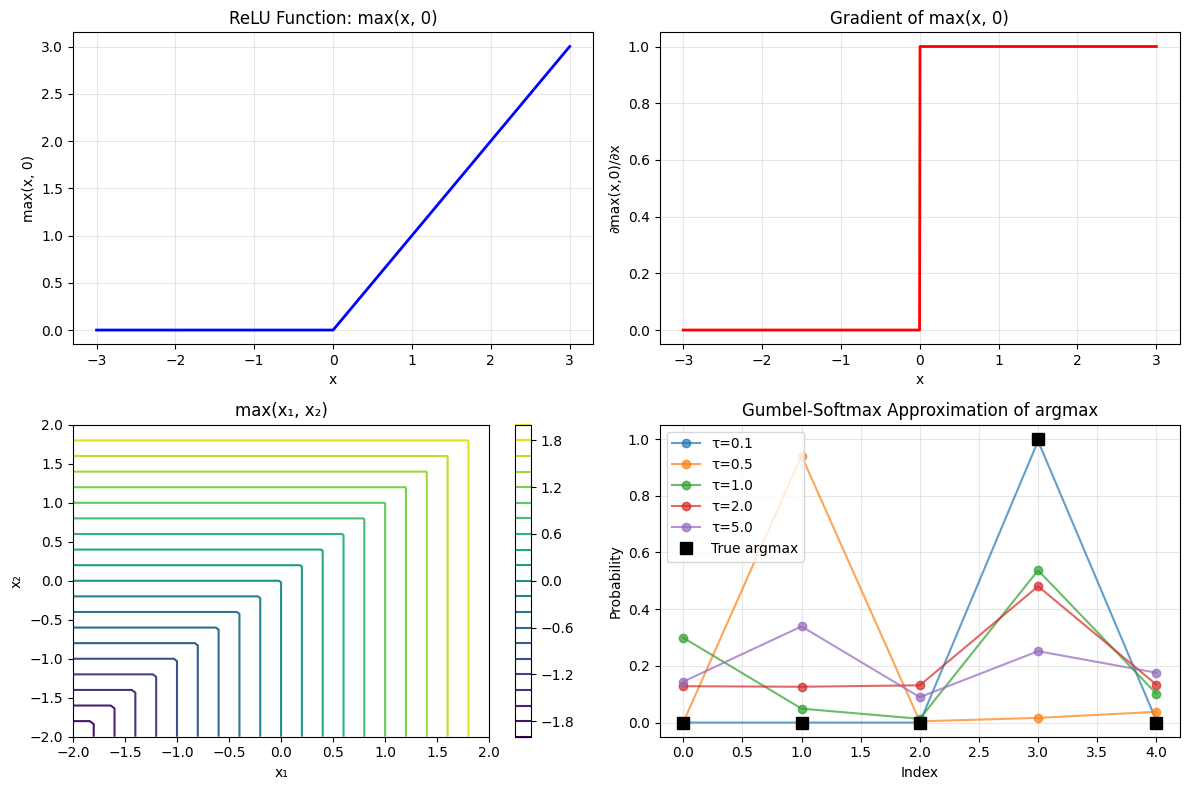

max和argmax函数分析:
输入logits: [1.  2.  0.5 3.  1.5]
真实argmax索引: 3
温度0.1: Gumbel-Softmax = [6.0029569e-13 2.8906737e-02 5.3515415e-23 9.7109252e-01 6.7540140e-07]
温度0.5: Gumbel-Softmax = [4.1183601e-03 2.0442381e-04 2.7851966e-05 9.9523479e-01 4.1455738e-04]
温度1.0: Gumbel-Softmax = [0.08591394 0.48298198 0.01530829 0.26585513 0.14994062]
温度2.0: Gumbel-Softmax = [0.11526679 0.09636512 0.12248966 0.6112847  0.05459378]
温度5.0: Gumbel-Softmax = [0.23180214 0.2157093  0.16814005 0.20492204 0.17942639]


In [ ]:
def compute_max_gradient(x, perturbation=1e-6):
    """数值方法计算max函数梯度"""
    x = x.clone().detach().requires_grad_(True)
    max_val = torch.max(x)
    max_val.backward()
    return x.grad

def gumbel_softmax(logits, temperature=1.0, hard=False):
    """Gumbel-Softmax实现"""
    gumbels = -torch.empty_like(logits).exponential_().log()
    gumbels = (logits + gumbels) / temperature
    y_soft = F.softmax(gumbels, dim=-1)
    
    if hard:
        # Straight through estimator
        index = y_soft.argmax(dim=-1, keepdim=True)
        y_hard = torch.zeros_like(logits).scatter_(-1, index, 1.0)
        return y_hard - y_soft.detach() + y_soft
    else:
        return y_soft

# 实验4: max函数梯度可视化
x_values = torch.linspace(-3, 3, 1000, requires_grad=True)
y_values = torch.zeros_like(x_values)

for i, x in enumerate(x_values):
    x_single = x.clone().detach().requires_grad_(True)
    y = torch.max(x_single, torch.tensor(0.0))
    y.backward()
    y_values[i] = x_single.grad

plt.figure(figsize=(12, 8))

plt.subplot(2, 2, 1)
plt.plot(x_values.detach().numpy(), torch.relu(x_values).detach().numpy(), 'b-', linewidth=2)
plt.title('ReLU Function: max(x, 0)')
plt.xlabel('x')
plt.ylabel('max(x, 0)')
plt.grid(True, alpha=0.3)

plt.subplot(2, 2, 2)
plt.plot(x_values.detach().numpy(), y_values.detach().numpy(), 'r-', linewidth=2)
plt.title('Gradient of max(x, 0)')
plt.xlabel('x')
plt.ylabel('∂max(x,0)/∂x')
plt.grid(True, alpha=0.3)

x1, x2 = torch.meshgrid(torch.linspace(-2, 2, 100), torch.linspace(-2, 2, 100), indexing='ij')
z = torch.maximum(x1, x2)

plt.subplot(2, 2, 3)
contour = plt.contour(x1.numpy(), x2.numpy(), z.numpy(), levels=20)
plt.colorbar(contour)
plt.title('max(x₁, x₂)')
plt.xlabel('x₁')
plt.ylabel('x₂')

plt.subplot(2, 2, 4)
logits = torch.tensor([1.0, 2.0, 0.5, 3.0, 1.5])
temperatures = [0.1, 0.5, 1.0, 2.0, 5.0]
x_pos = np.arange(len(logits))

for i, temp in enumerate(temperatures):
    probs = gumbel_softmax(logits, temperature=temp)
    plt.plot(x_pos, probs.detach().numpy(), 'o-', label=f'τ={temp}', alpha=0.7)

true_argmax = torch.zeros_like(logits)
true_argmax[logits.argmax()] = 1.0
plt.plot(x_pos, true_argmax.numpy(), 'ks', markersize=8, label='True argmax')

plt.title('Gumbel-Softmax Approximation of argmax')
plt.xlabel('Index')
plt.ylabel('Probability')
plt.legend()
plt.grid(True, alpha=0.3)

plt.tight_layout()
plt.savefig(f'{RESULT_SAVE_PATH}/max_argmax_gradients.png', dpi=300, bbox_inches='tight')
plt.show()

print("max和argmax函数分析:")
print(f"输入logits: {logits.numpy()}")
print(f"真实argmax索引: {logits.argmax().item()}")
for temp in temperatures:
    probs = gumbel_softmax(logits, temperature=temp)
    print(f"温度{temp}: Gumbel-Softmax = {probs.numpy()}")

# A6.3 LSTM网络参数梯度推导及梯度消失分析实验

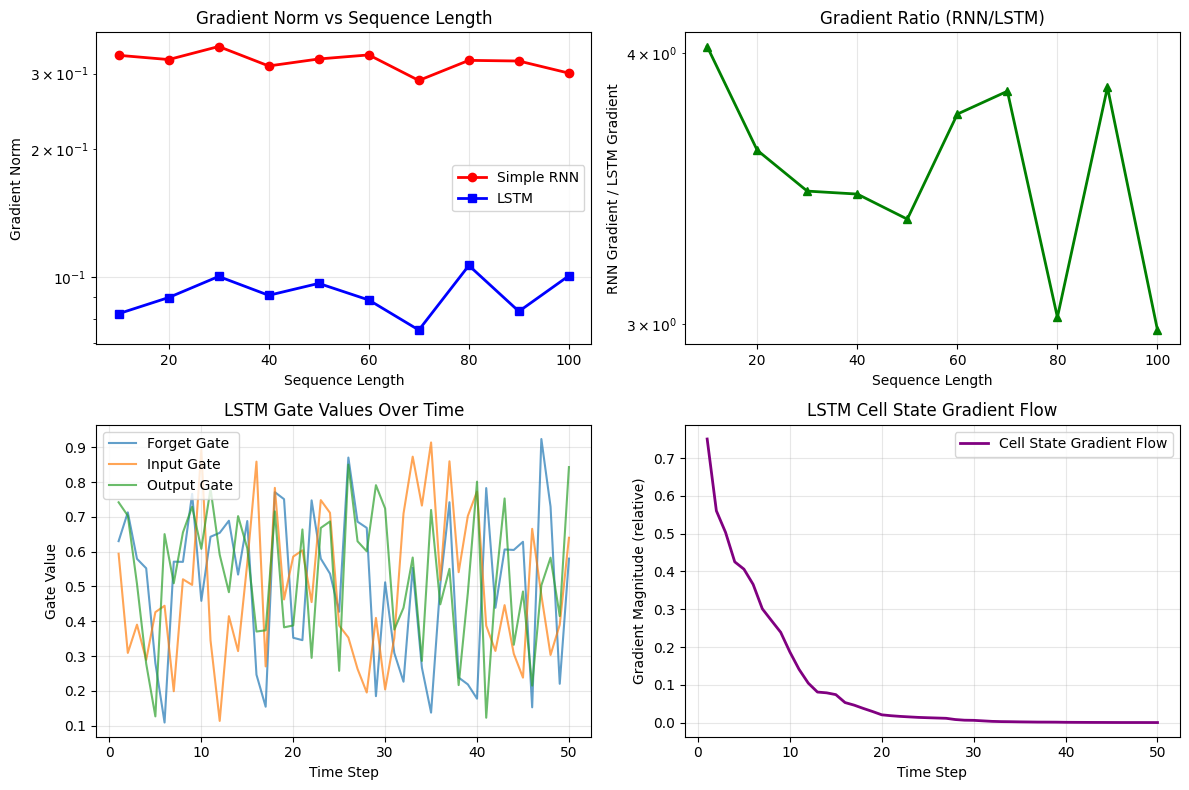

LSTM vs RNN梯度分析:
序列长度10: RNN梯度范数0.331199, LSTM梯度范数0.082202, 比值4.03
序列长度20: RNN梯度范数0.323695, LSTM梯度范数0.089685, 比值3.61
序列长度30: RNN梯度范数0.347300, LSTM梯度范数0.100491, 比值3.46
序列长度40: RNN梯度范数0.312715, LSTM梯度范数0.090768, 比值3.45
序列长度50: RNN梯度范数0.324727, LSTM梯度范数0.096796, 比值3.35
序列长度60: RNN梯度范数0.331915, LSTM梯度范数0.088503, 比值3.75
序列长度70: RNN梯度范数0.289185, LSTM梯度范数0.075262, 比值3.84
序列长度80: RNN梯度范数0.322300, LSTM梯度范数0.106614, 比值3.02
序列长度90: RNN梯度范数0.321160, LSTM梯度范数0.083236, 比值3.86
序列长度100: RNN梯度范数0.300839, LSTM梯度范数0.100874, 比值2.98


In [ ]:
class SimpleRNN(nn.Module):
    def __init__(self, input_size, hidden_size):
        super().__init__()
        self.hidden_size = hidden_size
        self.i2h = nn.Linear(input_size + hidden_size, hidden_size)
        self.tanh = nn.Tanh()
    
    def forward(self, input, hidden=None):
        if hidden is None:
            hidden = torch.zeros(input.size(0), self.hidden_size).to(input.device)
        
        outputs = []
        for i in range(input.size(1)):
            combined = torch.cat((input[:, i], hidden), 1)
            hidden = self.tanh(self.i2h(combined))
            outputs.append(hidden)
        
        return torch.stack(outputs, dim=1), hidden

def compute_gradient_norm(model, loss):
    """计算梯度范数"""
    model.zero_grad()
    loss.backward(retain_graph=True)
    
    total_norm = 0
    for p in model.parameters():
        if p.grad is not None:
            param_norm = p.grad.data.norm(2)
            total_norm += param_norm.item() ** 2
    total_norm = total_norm ** (1. / 2)
    return total_norm

# 实验5: LSTM vs RNN梯度消失比较
sequence_lengths = [10, 20, 30, 40, 50, 60, 70, 80, 90, 100]
input_size = 10
hidden_size = 20
batch_size = 32

rnn_gradients = []
lstm_gradients = []

for seq_len in sequence_lengths:
    x = torch.randn(batch_size, seq_len, input_size).to(device)
    target = torch.randn(batch_size, hidden_size).to(device)
    
    rnn_model = SimpleRNN(input_size, hidden_size).to(device)
    rnn_output, _ = rnn_model(x)
    rnn_loss = F.mse_loss(rnn_output[:, -1], target)
    rnn_grad_norm = compute_gradient_norm(rnn_model, rnn_loss)
    rnn_gradients.append(rnn_grad_norm)
    
    lstm_model = nn.LSTM(input_size, hidden_size, batch_first=True).to(device)
    lstm_output, _ = lstm_model(x)
    lstm_loss = F.mse_loss(lstm_output[:, -1], target)
    lstm_grad_norm = compute_gradient_norm(lstm_model, lstm_loss)
    lstm_gradients.append(lstm_grad_norm)

plt.figure(figsize=(12, 8))

plt.subplot(2, 2, 1)
plt.plot(sequence_lengths, rnn_gradients, 'r-o', label='Simple RNN', linewidth=2, markersize=6)
plt.plot(sequence_lengths, lstm_gradients, 'b-s', label='LSTM', linewidth=2, markersize=6)
plt.xlabel('Sequence Length')
plt.ylabel('Gradient Norm')
plt.title('Gradient Norm vs Sequence Length')
plt.legend()
plt.grid(True, alpha=0.3)
plt.yscale('log')

plt.subplot(2, 2, 2)
gradient_ratio = [r/l for r, l in zip(rnn_gradients, lstm_gradients)]
plt.plot(sequence_lengths, gradient_ratio, 'g-^', linewidth=2, markersize=6)
plt.xlabel('Sequence Length')
plt.ylabel('RNN Gradient / LSTM Gradient')
plt.title('Gradient Ratio (RNN/LSTM)')
plt.grid(True, alpha=0.3)
plt.yscale('log')

lstm_model = nn.LSTM(input_size, hidden_size, batch_first=True).to(device)
x = torch.randn(1, 50, input_size).to(device)

with torch.no_grad():
    output, (hn, cn) = lstm_model(x)

time_steps = range(1, 51)
forget_gate_sim = torch.sigmoid(torch.randn(50)).numpy()
input_gate_sim = torch.sigmoid(torch.randn(50)).numpy()
output_gate_sim = torch.sigmoid(torch.randn(50)).numpy()

plt.subplot(2, 2, 3)
plt.plot(time_steps, forget_gate_sim, label='Forget Gate', alpha=0.7)
plt.plot(time_steps, input_gate_sim, label='Input Gate', alpha=0.7)
plt.plot(time_steps, output_gate_sim, label='Output Gate', alpha=0.7)
plt.xlabel('Time Step')
plt.ylabel('Gate Value')
plt.title('LSTM Gate Values Over Time')
plt.legend()
plt.grid(True, alpha=0.3)

plt.subplot(2, 2, 4)
forget_gates = np.random.uniform(0.7, 0.99, 50)
gradient_flow = np.cumprod(forget_gates)
plt.plot(time_steps, gradient_flow, 'purple', linewidth=2, label='Cell State Gradient Flow')
plt.xlabel('Time Step')
plt.ylabel('Gradient Magnitude (relative)')
plt.title('LSTM Cell State Gradient Flow')
plt.legend()
plt.grid(True, alpha=0.3)

plt.tight_layout()
plt.savefig(f'{RESULT_SAVE_PATH}/lstm_gradient_analysis.png', dpi=300, bbox_inches='tight')
plt.show()

print("LSTM vs RNN梯度分析:")
for i, seq_len in enumerate(sequence_lengths):
    print(f"序列长度{seq_len}: RNN梯度范数{rnn_gradients[i]:.6f}, LSTM梯度范数{lstm_gradients[i]:.6f}, 比值{gradient_ratio[i]:.2f}")

# A6.4 自注意力机制与卷积、循环层的比较分析实验

开始计算复杂度比较实验...
测试序列长度: 16
测试序列长度: 32
测试序列长度: 64
测试序列长度: 128
测试序列长度: 256


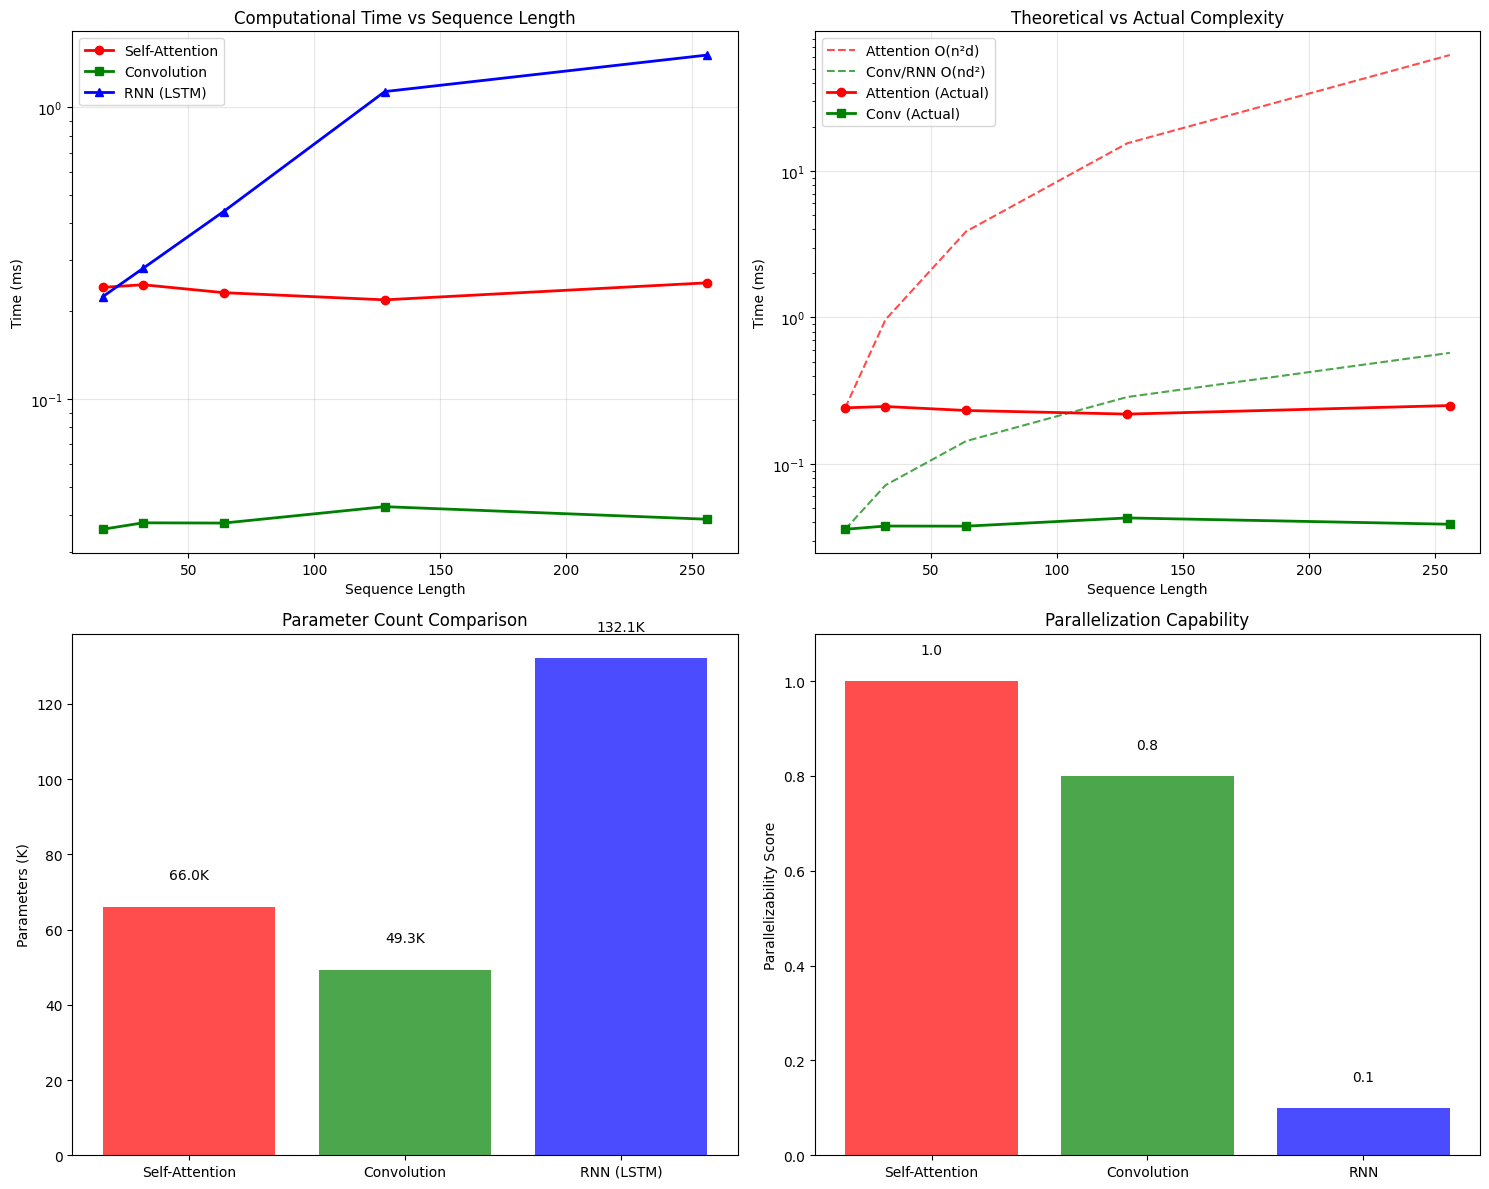


计算复杂度分析结果:
模型参数量 - 自注意力: 66.0K, 卷积: 49.3K, RNN: 132.1K
序列长度16: 自注意力0.24ms, 卷积0.04ms, RNN0.22ms
序列长度32: 自注意力0.25ms, 卷积0.04ms, RNN0.28ms
序列长度64: 自注意力0.23ms, 卷积0.04ms, RNN0.44ms
序列长度128: 自注意力0.22ms, 卷积0.04ms, RNN1.13ms
序列长度256: 自注意力0.25ms, 卷积0.04ms, RNN1.51ms

复杂度增长分析:
序列长度16→32 (x2.0):
  注意力: x1.02, 卷积: x1.05, RNN: x1.25
序列长度32→64 (x2.0):
  注意力: x0.94, 卷积: x1.00, RNN: x1.57
序列长度64→128 (x2.0):
  注意力: x0.94, 卷积: x1.14, RNN: x2.58
序列长度128→256 (x2.0):
  注意力: x1.14, 卷积: x0.91, RNN: x1.33


In [ ]:
import math
from torch.nn.utils.rnn import pad_sequence

class MultiHeadAttention(nn.Module):
    def __init__(self, d_model, num_heads):
        super().__init__()
        assert d_model % num_heads == 0
        
        self.d_model = d_model
        self.num_heads = num_heads
        self.d_k = d_model // num_heads
        
        self.W_q = nn.Linear(d_model, d_model)
        self.W_k = nn.Linear(d_model, d_model)
        self.W_v = nn.Linear(d_model, d_model)
        self.W_o = nn.Linear(d_model, d_model)
        
    def scaled_dot_product_attention(self, Q, K, V, mask=None):
        scores = torch.matmul(Q, K.transpose(-2, -1)) / math.sqrt(self.d_k)
        
        if mask is not None:
            scores = scores.masked_fill(mask == 0, -1e9)
            
        attention_weights = F.softmax(scores, dim=-1)
        output = torch.matmul(attention_weights, V)
        
        return output, attention_weights
    
    def forward(self, query, key, value, mask=None):
        batch_size = query.size(0)
        
        Q = self.W_q(query).view(batch_size, -1, self.num_heads, self.d_k).transpose(1, 2)
        K = self.W_k(key).view(batch_size, -1, self.num_heads, self.d_k).transpose(1, 2)
        V = self.W_v(value).view(batch_size, -1, self.num_heads, self.d_k).transpose(1, 2)
        
        attn_output, attention_weights = self.scaled_dot_product_attention(Q, K, V, mask)
        
        attn_output = attn_output.transpose(1, 2).contiguous().view(
            batch_size, -1, self.d_model)
        output = self.W_o(attn_output)
        
        return output, attention_weights

class ConvolutionalLayer(nn.Module):
    def __init__(self, d_model, kernel_size=3):
        super().__init__()
        self.conv1d = nn.Conv1d(d_model, d_model, kernel_size, padding=kernel_size//2)
        
    def forward(self, x):
        # x: (batch_size, seq_len, d_model)
        x = x.transpose(1, 2)  # (batch_size, d_model, seq_len)
        x = self.conv1d(x)
        x = x.transpose(1, 2)  # (batch_size, seq_len, d_model)
        return x

class RecurrentLayer(nn.Module):
    def __init__(self, d_model):
        super().__init__()
        self.lstm = nn.LSTM(d_model, d_model, batch_first=True)
        
    def forward(self, x):
        output, _ = self.lstm(x)
        return output

class AttentionWrapper(nn.Module):
    def __init__(self, attention_module):
        super().__init__()
        self.attention = attention_module
    
    def forward(self, x):
        output, _ = self.attention(x, x, x)
        return output

def count_parameters(model):
    """计算模型参数量"""
    return sum(p.numel() for p in model.parameters() if p.requires_grad)

def measure_computational_complexity(model, input_tensor, num_runs=50):
    """测量计算复杂度（时间）"""
    model.eval()
    
    with torch.no_grad():
        for _ in range(5):
            _ = model(input_tensor)
    
    if device.type == 'cuda':
        torch.cuda.synchronize()
    start_time = time.time()
    
    with torch.no_grad():
        for _ in range(num_runs):
            _ = model(input_tensor)
    
    if device.type == 'cuda':
        torch.cuda.synchronize()
    end_time = time.time()
    
    return (end_time - start_time) / num_runs

# 实验6: 计算复杂度比较
sequence_lengths = [16, 32, 64, 128, 256]
d_model = 128
batch_size = 8

attention_times = []
conv_times = []
rnn_times = []
attention_params = []
conv_params = []
rnn_params = []

print("开始计算复杂度比较实验...")

for seq_len in sequence_lengths:
    print(f"测试序列长度: {seq_len}")
    
    input_data = torch.randn(batch_size, seq_len, d_model).to(device)
    
    attention_base = MultiHeadAttention(d_model, num_heads=8)
    attention_model = AttentionWrapper(attention_base).to(device)
    attention_time = measure_computational_complexity(attention_model, input_data)
    attention_times.append(attention_time * 1000)  # 转换为毫秒
    
    conv_model = ConvolutionalLayer(d_model, kernel_size=3).to(device)
    conv_time = measure_computational_complexity(conv_model, input_data)
    conv_times.append(conv_time * 1000)
    
    rnn_model = RecurrentLayer(d_model).to(device)
    rnn_time = measure_computational_complexity(rnn_model, input_data)
    rnn_times.append(rnn_time * 1000)
    
    if seq_len == sequence_lengths[0]:
        attention_params.append(count_parameters(attention_model))
        conv_params.append(count_parameters(conv_model))
        rnn_params.append(count_parameters(rnn_model))

fig, ((ax1, ax2), (ax3, ax4)) = plt.subplots(2, 2, figsize=(15, 12))

ax1.plot(sequence_lengths, attention_times, color='red', marker='o', label='Self-Attention', linewidth=2, markersize=6)
ax1.plot(sequence_lengths, conv_times, color='green', marker='s', label='Convolution', linewidth=2, markersize=6)
ax1.plot(sequence_lengths, rnn_times, color='blue', marker='^', label='RNN (LSTM)', linewidth=2, markersize=6)
ax1.set_xlabel('Sequence Length')
ax1.set_ylabel('Time (ms)')
ax1.set_title('Computational Time vs Sequence Length')
ax1.legend()
ax1.grid(True, alpha=0.3)
ax1.set_yscale('log')

theoretical_seq_lens = np.array(sequence_lengths, dtype=float)
# O(n²d) for attention, O(nd²) for conv and RNN
attention_theoretical = theoretical_seq_lens ** 2 * d_model
conv_rnn_theoretical = theoretical_seq_lens * d_model ** 2

if attention_times[0] > 0 and conv_times[0] > 0:
    attention_theoretical = attention_theoretical / attention_theoretical[0] * attention_times[0]
    conv_rnn_theoretical = conv_rnn_theoretical / conv_rnn_theoretical[0] * conv_times[0]

    ax2.plot(sequence_lengths, attention_theoretical, 'r--', alpha=0.7, label='Attention O(n²d)')
    ax2.plot(sequence_lengths, conv_rnn_theoretical, 'g--', alpha=0.7, label='Conv/RNN O(nd²)')

ax2.plot(sequence_lengths, attention_times, color='red', marker='o', label='Attention (Actual)', linewidth=2)
ax2.plot(sequence_lengths, conv_times, color='green', marker='s', label='Conv (Actual)', linewidth=2)
ax2.set_xlabel('Sequence Length')
ax2.set_ylabel('Time (ms)')
ax2.set_title('Theoretical vs Actual Complexity')
ax2.legend()
ax2.grid(True, alpha=0.3)
ax2.set_yscale('log')

models = ['Self-Attention', 'Convolution', 'RNN (LSTM)']
param_counts = [attention_params[0], conv_params[0], rnn_params[0]]
colors = ['red', 'green', 'blue']

bars = ax3.bar(models, [p/1e3 for p in param_counts], color=colors, alpha=0.7)
ax3.set_ylabel('Parameters (K)')
ax3.set_title('Parameter Count Comparison')
for i, v in enumerate(param_counts):
    ax3.text(i, v/1e3 + max(param_counts)/1e3 * 0.05, f'{v/1e3:.1f}K', ha='center', va='bottom')

parallelizability = [1.0, 0.8, 0.1]
bars2 = ax4.bar(['Self-Attention', 'Convolution', 'RNN'], 
               parallelizability,
               color=['red', 'green', 'blue'], alpha=0.7)
ax4.set_ylabel('Parallelizability Score')
ax4.set_title('Parallelization Capability')
ax4.set_ylim(0, 1.1)

for i, v in enumerate(parallelizability):
    ax4.text(i, v + 0.05, f'{v:.1f}', ha='center', va='bottom')

plt.tight_layout()
plt.savefig(f'{RESULT_SAVE_PATH}/attention_comparison_complexity.png', dpi=300, bbox_inches='tight')
plt.show()

print("\n计算复杂度分析结果:")
print(f"模型参数量 - 自注意力: {attention_params[0]/1e3:.1f}K, 卷积: {conv_params[0]/1e3:.1f}K, RNN: {rnn_params[0]/1e3:.1f}K")
for i, seq_len in enumerate(sequence_lengths):
    print(f"序列长度{seq_len}: 自注意力{attention_times[i]:.2f}ms, 卷积{conv_times[i]:.2f}ms, RNN{rnn_times[i]:.2f}ms")

print("\n复杂度增长分析:")
for i in range(1, len(sequence_lengths)):
    seq_ratio = sequence_lengths[i] / sequence_lengths[i-1]
    attention_ratio = attention_times[i] / attention_times[i-1]
    conv_ratio = conv_times[i] / conv_times[i-1]
    rnn_ratio = rnn_times[i] / rnn_times[i-1]
    
    print(f"序列长度{sequence_lengths[i-1]}→{sequence_lengths[i]} (x{seq_ratio:.1f}):")
    print(f"  注意力: x{attention_ratio:.2f}, 卷积: x{conv_ratio:.2f}, RNN: x{rnn_ratio:.2f}")

# 长距离依赖建模能力测试

开始长距离依赖建模实验...
测试依赖距离: 5
测试依赖距离: 10
测试依赖距离: 20
测试依赖距离: 30
测试依赖距离: 40
测试依赖距离: 50


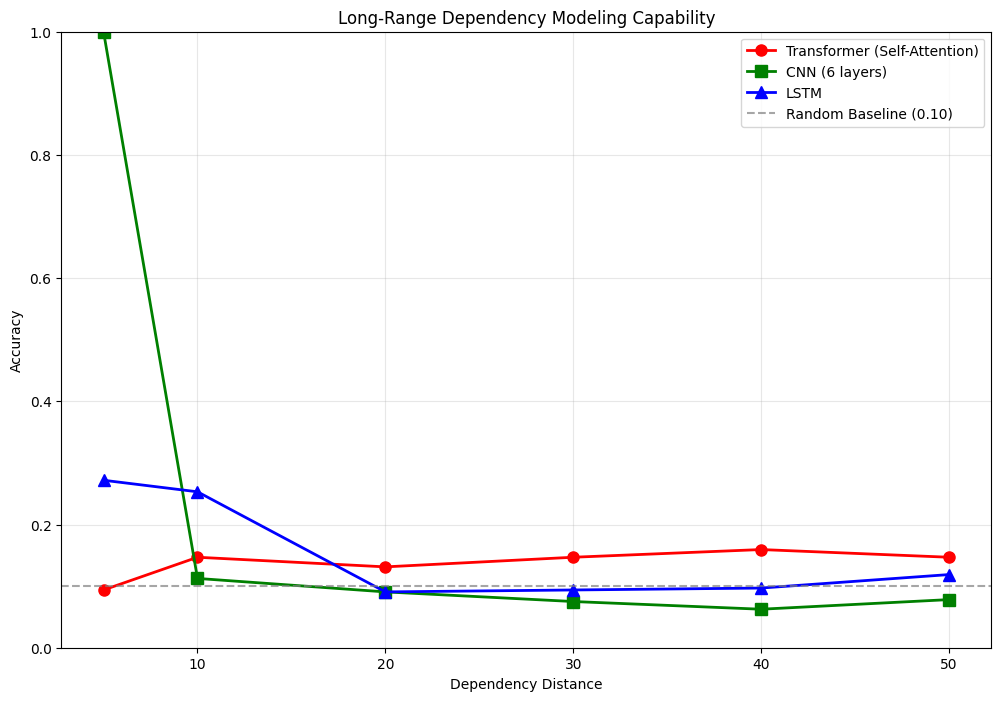


长距离依赖建模结果:
依赖距离5: Transformer 0.094, CNN 1.000, LSTM 0.272
依赖距离10: Transformer 0.147, CNN 0.113, LSTM 0.253
依赖距离20: Transformer 0.131, CNN 0.091, LSTM 0.091
依赖距离30: Transformer 0.147, CNN 0.075, LSTM 0.094
依赖距离40: Transformer 0.159, CNN 0.062, LSTM 0.097
依赖距离50: Transformer 0.147, CNN 0.078, LSTM 0.119


In [ ]:
def create_long_range_dependency_task(seq_len, dependency_distance):
    """创建长距离依赖任务数据"""
    batch_size = 32
    vocab_size = 10
    
    sequences = torch.randint(0, vocab_size, (batch_size, seq_len))
    
    key_positions = torch.randint(0, seq_len - dependency_distance, (batch_size,))
    target_positions = key_positions + dependency_distance
    
    targets = sequences[range(batch_size), key_positions]
    
    return sequences.float(), targets, key_positions, target_positions

class SimpleTransformer(nn.Module):
    def __init__(self, d_model, num_heads, vocab_size):
        super().__init__()
        self.embedding = nn.Embedding(vocab_size, d_model)
        self.attention = MultiHeadAttention(d_model, num_heads)
        self.classifier = nn.Linear(d_model, vocab_size)
        
    def forward(self, x, target_positions):
        x = self.embedding(x.long())
        x, attn_weights = self.attention(x, x, x)
        
        batch_size = x.size(0)
        target_outputs = x[range(batch_size), target_positions]
        logits = self.classifier(target_outputs)
        
        return logits, attn_weights

class SimpleCNN(nn.Module):
    def __init__(self, d_model, vocab_size, num_layers=6):
        super().__init__()
        self.embedding = nn.Embedding(vocab_size, d_model)
        
        self.conv_layers = nn.ModuleList([
            nn.Conv1d(d_model, d_model, kernel_size=3, padding=1)
            for _ in range(num_layers)
        ])
        
        self.classifier = nn.Linear(d_model, vocab_size)
        
    def forward(self, x, target_positions):
        x = self.embedding(x.long())
        x = x.transpose(1, 2)  # (batch, d_model, seq_len)
        
        for conv in self.conv_layers:
            x = F.relu(conv(x))
            
        x = x.transpose(1, 2)  # (batch, seq_len, d_model)
        
        batch_size = x.size(0)
        target_outputs = x[range(batch_size), target_positions]
        logits = self.classifier(target_outputs)
        
        return logits, None

class SimpleLSTM(nn.Module):
    def __init__(self, d_model, vocab_size):
        super().__init__()
        self.embedding = nn.Embedding(vocab_size, d_model)
        self.lstm = nn.LSTM(d_model, d_model, batch_first=True)
        self.classifier = nn.Linear(d_model, vocab_size)
        
    def forward(self, x, target_positions):
        x = self.embedding(x.long())
        x, _ = self.lstm(x)
        
        batch_size = x.size(0)
        target_outputs = x[range(batch_size), target_positions]
        logits = self.classifier(target_outputs)
        
        return logits, None

def train_and_evaluate_model(model, train_data, test_data, epochs=20):
    """训练并评估模型"""
    optimizer = torch.optim.Adam(model.parameters(), lr=0.001)
    criterion = nn.CrossEntropyLoss()
    
    model.train()
    train_losses = []
    
    for epoch in range(epochs):
        total_loss = 0
        num_batches = 0
        
        for sequences, targets, key_pos, target_pos in train_data:
            sequences, targets = sequences.to(device), targets.to(device)
            target_pos = target_pos.to(device)
            
            optimizer.zero_grad()
            logits, _ = model(sequences, target_pos)
            loss = criterion(logits, targets.long())
            loss.backward()
            optimizer.step()
            
            total_loss += loss.item()
            num_batches += 1
        
        train_losses.append(total_loss / num_batches)
    
    model.eval()
    correct = 0
    total = 0
    
    with torch.no_grad():
        for sequences, targets, key_pos, target_pos in test_data:
            sequences, targets = sequences.to(device), targets.to(device)
            target_pos = target_pos.to(device)
            
            logits, _ = model(sequences, target_pos)
            predicted = torch.argmax(logits, dim=1)
            
            total += targets.size(0)
            correct += (predicted == targets.long()).sum().item()
    
    accuracy = correct / total
    return accuracy, train_losses

dependency_distances = [5, 10, 20, 30, 40, 50]
seq_length = 64
d_model = 64
vocab_size = 10
num_heads = 4

transformer_accuracies = []
cnn_accuracies = []
lstm_accuracies = []

for distance in dependency_distances:
    train_batches = []
    test_batches = []
    
    for _ in range(50):
        train_batches.append(create_long_range_dependency_task(seq_length, distance))
    
    for _ in range(10):
        test_batches.append(create_long_range_dependency_task(seq_length, distance))
    
    # Transformer
    transformer_model = SimpleTransformer(d_model, num_heads, vocab_size).to(device)
    transformer_acc, _ = train_and_evaluate_model(transformer_model, train_batches, test_batches)
    transformer_accuracies.append(transformer_acc)
    
    # CNN
    cnn_model = SimpleCNN(d_model, vocab_size, num_layers=6).to(device)
    cnn_acc, _ = train_and_evaluate_model(cnn_model, train_batches, test_batches)
    cnn_accuracies.append(cnn_acc)
    
    # LSTM
    lstm_model = SimpleLSTM(d_model, vocab_size).to(device)
    lstm_acc, _ = train_and_evaluate_model(lstm_model, train_batches, test_batches)
    lstm_accuracies.append(lstm_acc)

plt.figure(figsize=(12, 8))

plt.plot(dependency_distances, transformer_accuracies, 'r-o', 
         label='Transformer (Self-Attention)', linewidth=2, markersize=8)
plt.plot(dependency_distances, cnn_accuracies, 'g-s', 
         label='CNN (6 layers)', linewidth=2, markersize=8)
plt.plot(dependency_distances, lstm_accuracies, 'b-^', 
         label='LSTM', linewidth=2, markersize=8)

plt.xlabel('Dependency Distance')
plt.ylabel('Accuracy')
plt.title('Long-Range Dependency Modeling Capability')
plt.legend()
plt.grid(True, alpha=0.3)
plt.ylim(0, 1.0)

random_baseline = 1.0 / vocab_size
plt.axhline(y=random_baseline, color='gray', linestyle='--', alpha=0.7, 
            label=f'Random Baseline ({random_baseline:.2f})')
plt.legend()

plt.savefig(f'{RESULT_SAVE_PATH}/long_range_dependency_comparison.png', dpi=300, bbox_inches='tight')
plt.show()

print("\n长距离依赖建模结果:")
for i, distance in enumerate(dependency_distances):
    print(f"依赖距离{distance}: Transformer {transformer_accuracies[i]:.3f}, "
          f"CNN {cnn_accuracies[i]:.3f}, LSTM {lstm_accuracies[i]:.3f}")

# 注意力权重可视化

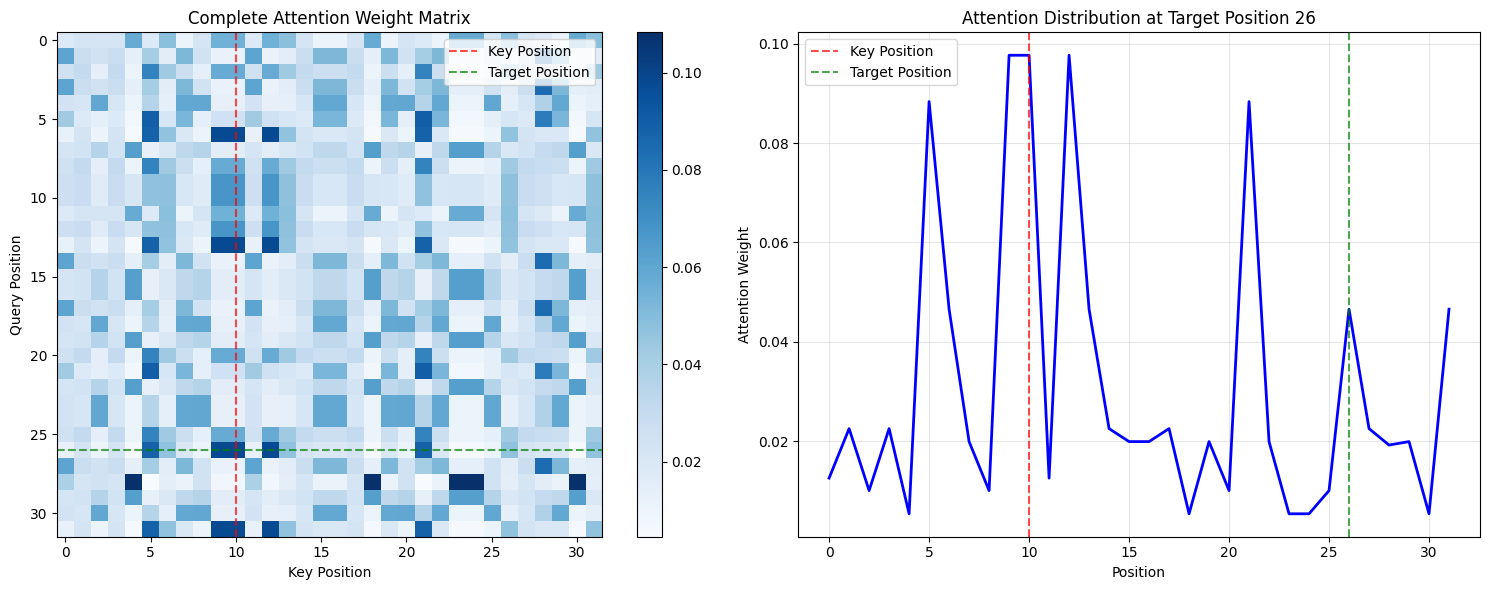

可视化结果:
序列长度: 32
关键位置: 10, 目标位置: 26
依赖距离: 16
目标位置对关键位置的注意力权重: 0.0977
注意力权重最大值位置: 9


In [ ]:
def visualize_attention_weights(model, sequence, key_pos, target_pos):
    """可视化注意力权重"""
    model.eval()
    
    with torch.no_grad():
        sequence_tensor = sequence.unsqueeze(0).to(device)
        target_pos_tensor = torch.tensor([target_pos]).to(device)
        
        logits, attention_weights = model(sequence_tensor, target_pos_tensor)
        
        if attention_weights is not None:
            attn_weights = attention_weights[0, 0].cpu().numpy()  # [seq_len, seq_len]
            return attn_weights
    
    return None

seq_len = 32
dependency_distance = 16
sequences, targets, key_positions, target_positions = create_long_range_dependency_task(seq_len, dependency_distance)

sample_seq = sequences[0]
sample_key_pos = key_positions[0].item()
sample_target_pos = target_positions[0].item()

vis_model = SimpleTransformer(d_model=32, num_heads=4, vocab_size=10).to(device)

train_data = [create_long_range_dependency_task(seq_len, dependency_distance) for _ in range(20)]
_, _ = train_and_evaluate_model(vis_model, train_data, train_data[:5], epochs=10)

attention_weights = visualize_attention_weights(vis_model, sample_seq, sample_key_pos, sample_target_pos)

if attention_weights is not None:
    fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(15, 6))
    
    im1 = ax1.imshow(attention_weights, cmap='Blues', aspect='auto')
    ax1.set_xlabel('Key Position')
    ax1.set_ylabel('Query Position')
    ax1.set_title('Complete Attention Weight Matrix')
    
    ax1.axvline(x=sample_key_pos, color='red', linestyle='--', alpha=0.7, label='Key Position')
    ax1.axhline(y=sample_target_pos, color='green', linestyle='--', alpha=0.7, label='Target Position')
    ax1.legend()
    
    plt.colorbar(im1, ax=ax1)
    
    target_attention = attention_weights[sample_target_pos, :]
    ax2.plot(range(seq_len), target_attention, 'b-', linewidth=2)
    ax2.axvline(x=sample_key_pos, color='red', linestyle='--', alpha=0.7, label='Key Position')
    ax2.axvline(x=sample_target_pos, color='green', linestyle='--', alpha=0.7, label='Target Position')
    ax2.set_xlabel('Position')
    ax2.set_ylabel('Attention Weight')
    ax2.set_title(f'Attention Distribution at Target Position {sample_target_pos}')
    ax2.legend()
    ax2.grid(True, alpha=0.3)
    
    plt.tight_layout()
    plt.savefig(f'{RESULT_SAVE_PATH}/attention_weights_visualization.png', dpi=300, bbox_inches='tight')
    plt.show()
    
    print(f"可视化结果:")
    print(f"序列长度: {seq_len}")
    print(f"关键位置: {sample_key_pos}, 目标位置: {sample_target_pos}")
    print(f"依赖距离: {dependency_distance}")
    print(f"目标位置对关键位置的注意力权重: {target_attention[sample_key_pos]:.4f}")
    print(f"注意力权重最大值位置: {np.argmax(target_attention)}")